Looking at all 5 outputs, here's my analysis:

**Immediately eliminate:**
- **v3 (Bandpass energy ratio + Azimuthal asymmetry)** — Ch1 is pure noise/ringing artifacts, and Ch2 shows identical concentric rings for all 3 classes. Zero discriminative power.
- **Baseline CNN (Gradient + Laplacian)** — Laplacian is mostly noise. These are CNN-style local features; FNO's spectral convolution doesn't benefit from them the way a CNN would.
- **v1 FNO original (Log PSD + Phase coherence)** — Ch2 (phase coherence) is uniform noise across all classes. Ch1 (log PSD) looks identical across classes — the irfft2 reconstruction loses all spatial localization.

**The real contest is v4 vs v5:**

**v4 (Gaussian bandpass + Angular gradient)** is strong — bandpass cleanly preserves the ring structure with subhalo spots visible, angular gradient sharply localizes the subhalo position. But the bandpass and angular gradient are somewhat redundant with each other.

**v5 (Polar + Angular gradient + Radial deviation + Point symmetry residual)** is the best overall. Here's why:

- **Ch1 Polar transform** is uniquely powerful for FNO — it converts the ring into a horizontal stripe, so FNO's spectral convolution directly encodes ring frequency in the dominant horizontal mode. Subhalo → vertical spike. This is the most FNO-native representation.
- **Ch2 Angular gradient** localizes the subhalo angularly.
- **Ch3 Radial deviation** captures the spiral/vortex structure very clearly — look at how different the swirl patterns are across classes.
- **Ch4 Point symmetry residual** adds orthogonal information: it directly measures symmetry breaking, which is exactly what separates the three classes physically.

The four channels in v5 are also more **informationally orthogonal** — each captures a genuinely different geometric property, whereas v4's bandpass and angular gradient are both essentially "where is the bright spot on the ring."

**Go with v5.**

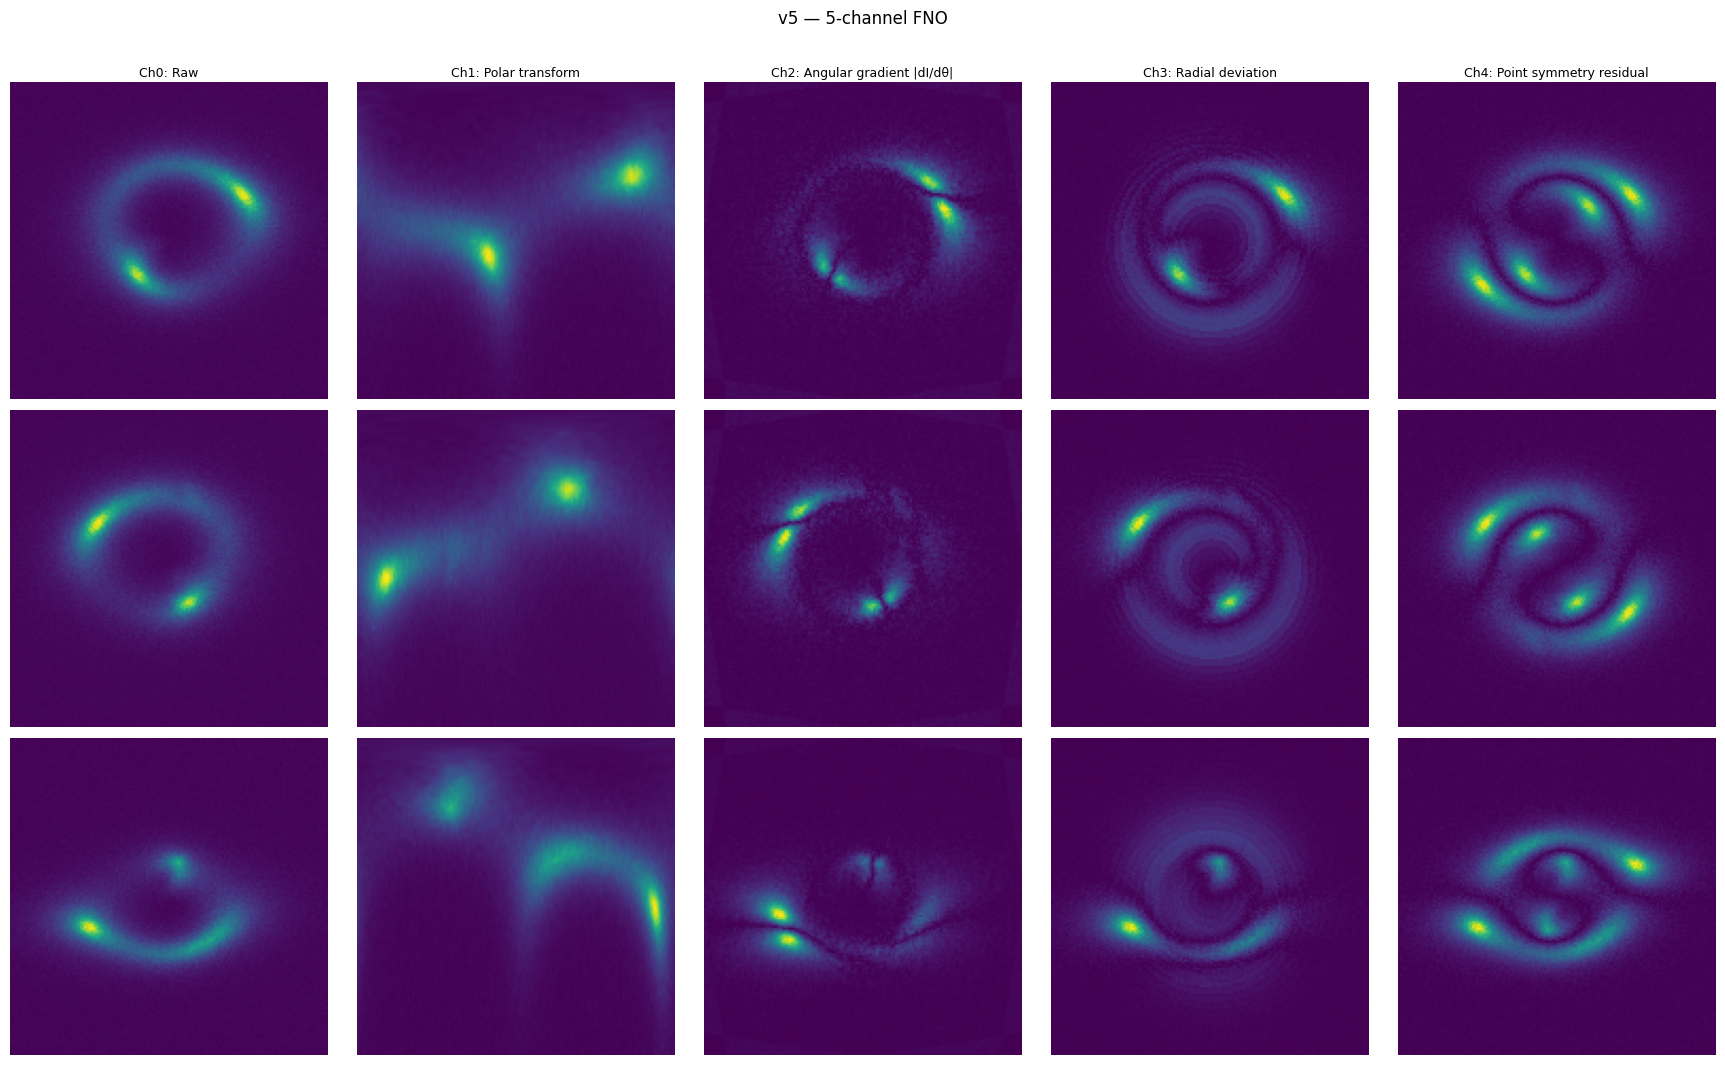

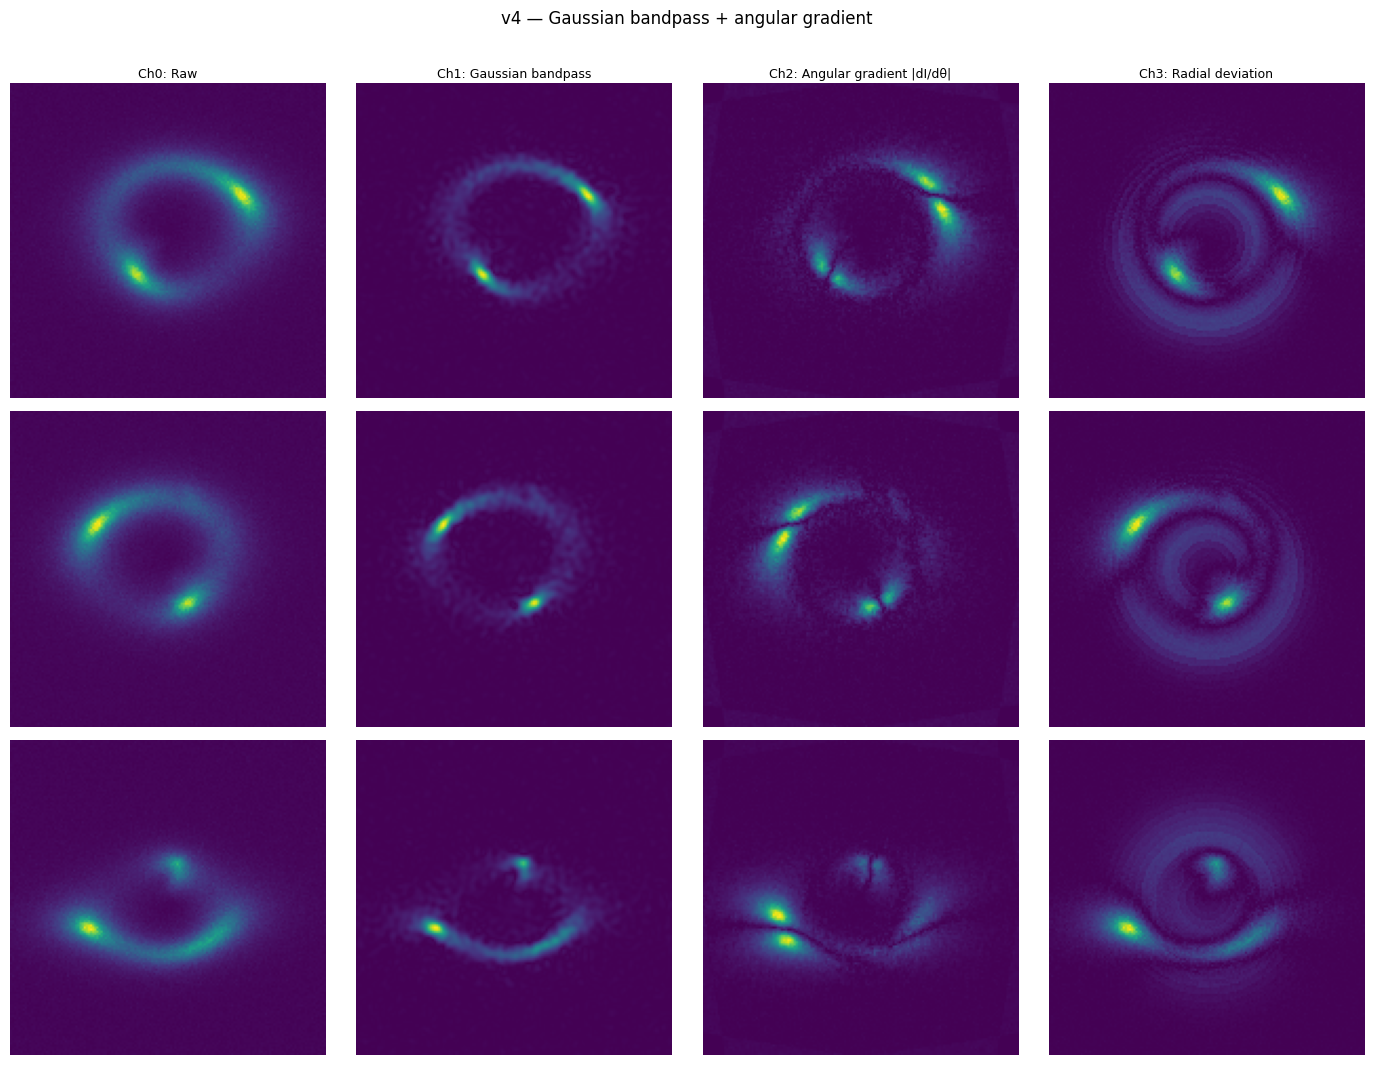

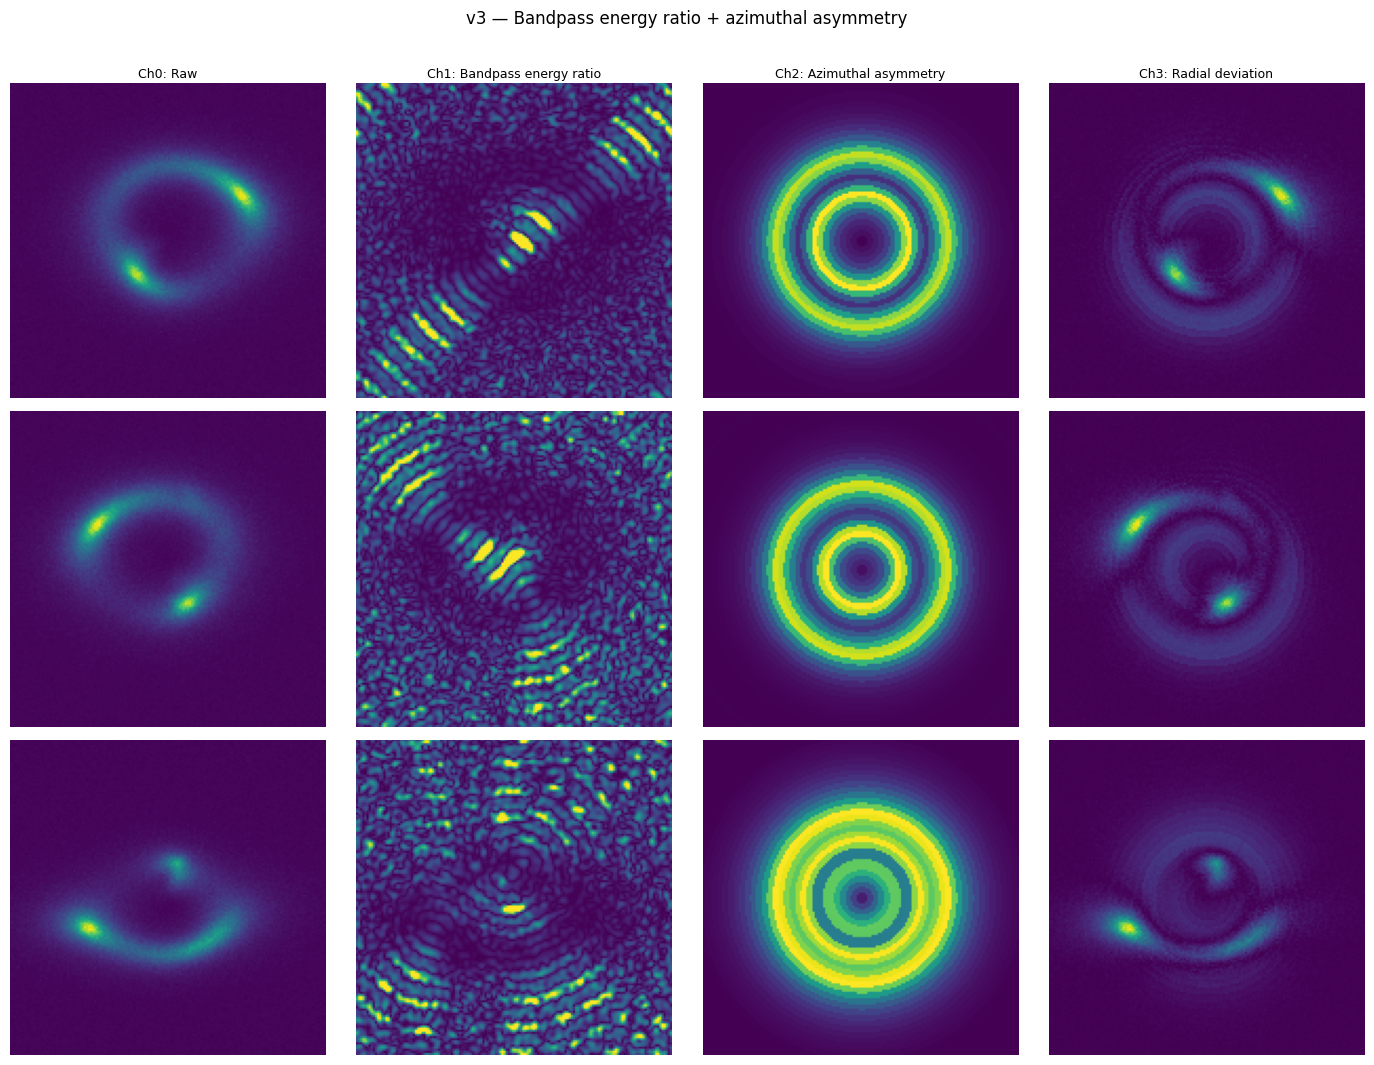

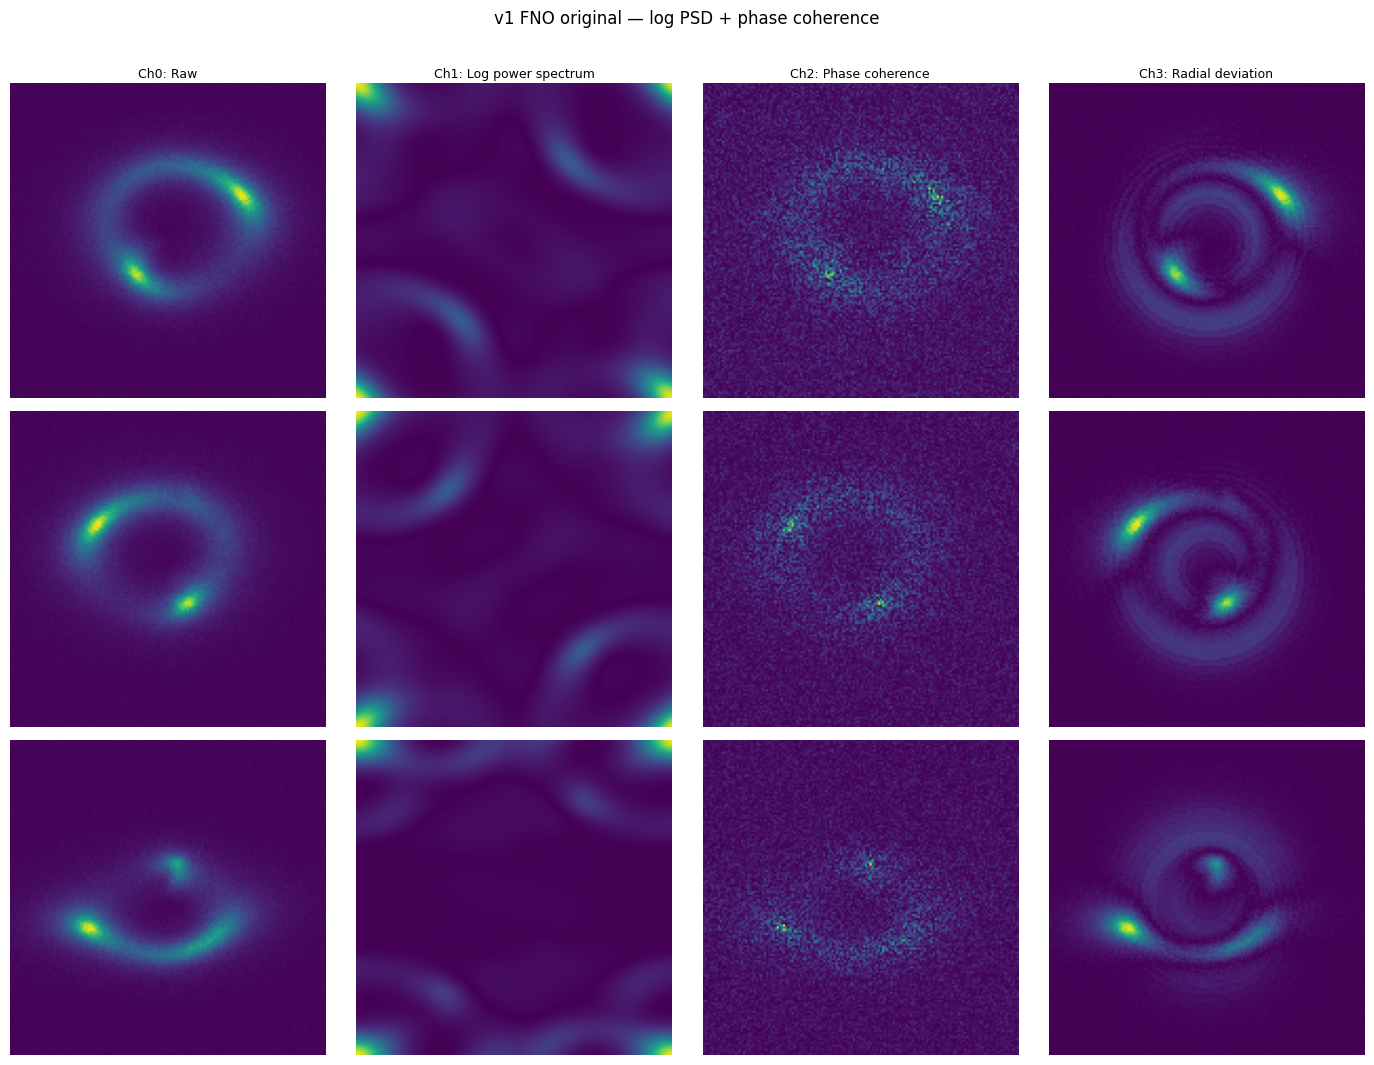

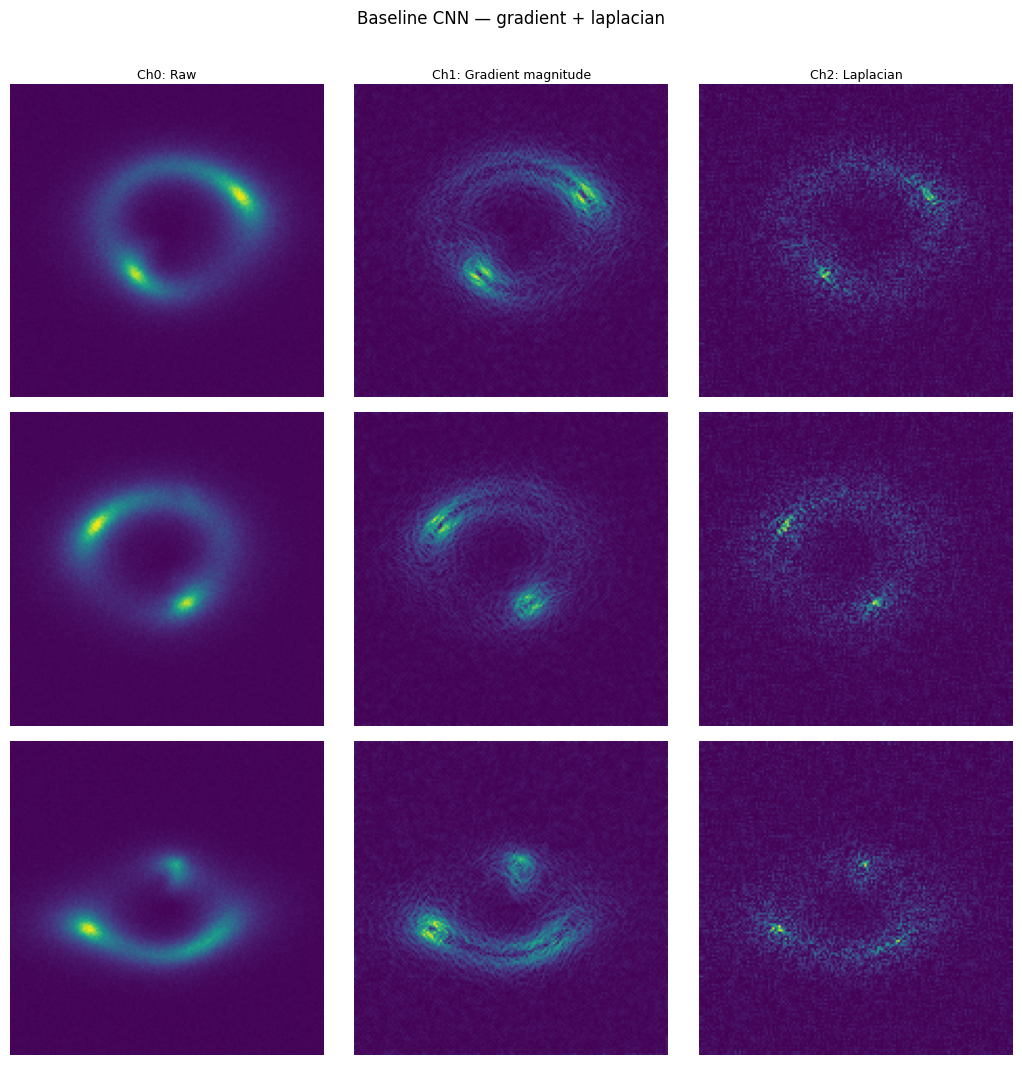

In [2]:
import numpy as np
import os
import random
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


# ── Channel functions ─────────────────────────────────────────────────────────

def ch_raw(img):
    """Ch0: Raw image — no transform."""
    return img


def ch_polar_transform(img):
    """Ch1 (v1/v2): Cartesian → Polar remapping.
    Einstein ring → horizontal stripe.
    Subhalo → vertical spike. Vortex → wavy stripe."""
    eps = 1e-8
    H, W = img.shape[-2], img.shape[-1]
    cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
    r_max = min(cx, cy)
    r_vals     = torch.linspace(0, r_max, H)
    theta_vals = torch.linspace(-torch.pi, torch.pi, W)
    R, THETA = torch.meshgrid(r_vals, theta_vals, indexing='ij')
    gx = ((cx + R * torch.cos(THETA)) / (W - 1)) * 2 - 1
    gy = ((cy + R * torch.sin(THETA)) / (H - 1)) * 2 - 1
    grid  = torch.stack([gx, gy], dim=-1).unsqueeze(0)
    polar = F.grid_sample(img.unsqueeze(0), grid, mode='bilinear',
                           padding_mode='zeros', align_corners=True).squeeze()
    return ((polar - polar.min()) / (polar.max() - polar.min() + eps)).unsqueeze(0)


def ch_angular_gradient(img):
    """Ch2 (v1/v2/v4): |dI/dθ| per pixel in polar coordinates.
    no_sub → near-zero. Subhalo → sharp spike. Vortex → distributed."""
    eps = 1e-8
    H, W = img.shape[-2], img.shape[-1]
    cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
    ys = torch.arange(H, dtype=torch.float32).unsqueeze(1).expand(H, W)
    xs = torch.arange(W, dtype=torch.float32).unsqueeze(0).expand(H, W)
    radii  = torch.sqrt((xs - cx)**2 + (ys - cy)**2).clamp(min=1.0)
    angles = torch.atan2(ys - cy, xs - cx)
    dtheta = 0.15

    def _sample(r, theta):
        x = (cx + r * torch.cos(theta)) / (W - 1) * 2 - 1
        y = (cy + r * torch.sin(theta)) / (H - 1) * 2 - 1
        return torch.stack([x, y], dim=-1).unsqueeze(0)

    I  = img.unsqueeze(0)
    Ip = F.grid_sample(I, _sample(radii, angles + dtheta),
                        mode='bilinear', padding_mode='zeros', align_corners=True).squeeze()
    Im = F.grid_sample(I, _sample(radii, angles - dtheta),
                        mode='bilinear', padding_mode='zeros', align_corners=True).squeeze()
    ag = (Ip - Im).abs() / (2 * dtheta)
    return ((ag - ag.min()) / (ag.max() - ag.min() + eps)).unsqueeze(0)


def ch_radial_deviation(img):
    """Ch3 (all versions): |I - ring_mean| per pixel.
    Perfect ring → zero. Subhalo → localized spot. Vortex → extended."""
    eps = 1e-8
    H, W = img.shape[-2], img.shape[-1]
    cx, cy = W / 2.0, H / 2.0
    ys = torch.arange(H, dtype=torch.float32).unsqueeze(1).expand(H, W)
    xs = torch.arange(W, dtype=torch.float32).unsqueeze(0).expand(H, W)
    radii   = torch.sqrt((xs - cx)**2 + (ys - cy)**2)
    bin_idx = (radii / (radii.max() + eps) * 30).long().clamp(0, 29)
    I = img[0]; dev = torch.zeros_like(I)
    for b in range(30):
        mask = (bin_idx == b)
        if mask.sum() > 0:
            dev[mask] = (I[mask] - I[mask].mean()).abs()
    return ((dev - dev.min()) / (dev.max() - dev.min() + eps)).unsqueeze(0)


def ch_point_symmetry_residual(img):
    """Ch4 (v1 5-ch): |I(x,y) - I(-x,-y)| — point symmetry breaking.
    Perfect Einstein ring → near zero. Subhalo → bright localized spot."""
    eps = 1e-8
    flipped  = torch.flip(img, dims=[-1, -2])
    residual = (img - flipped).abs()
    return ((residual - residual.min()) / (residual.max() - residual.min() + eps))


def ch_gaussian_bandpass(img):
    """Ch1 (v4): Gaussian bandpass at mid-frequency (centre=0.15, sigma=0.07).
    No ringing. Subhalo → concentrated bright spot. Vortex → distributed."""
    eps = 1e-8
    H, W = img.shape[-2], img.shape[-1]
    ft = torch.fft.rfft2(img[0], norm="ortho")
    fy = torch.fft.fftfreq(H)
    fx = torch.fft.rfftfreq(W)
    FY, FX = torch.meshgrid(fy, fx, indexing='ij')
    R = torch.sqrt(FY**2 + FX**2)
    R0, sigma = 0.15, 0.07
    gauss_weight = torch.exp(-((R - R0)**2) / (2 * sigma**2))
    filtered = torch.fft.irfft2(ft * gauss_weight, s=(H, W), norm="ortho").abs()
    return ((filtered - filtered.min()) / (filtered.max() - filtered.min() + eps)).unsqueeze(0)


def ch_azimuthal_asymmetry(img):
    """Ch2 (v3): Angular std of intensity per radial ring.
    no_sub → low std. Subhalo → high std at one ring. Vortex → elevated across rings."""
    eps = 1e-8
    H, W = img.shape[-2], img.shape[-1]
    cx, cy = W / 2.0, H / 2.0
    ys = torch.arange(H, dtype=torch.float32).unsqueeze(1).expand(H, W)
    xs = torch.arange(W, dtype=torch.float32).unsqueeze(0).expand(H, W)
    radii   = torch.sqrt((xs - cx)**2 + (ys - cy)**2)
    bin_idx = (radii / (radii.max() + eps) * 40).long().clamp(0, 39)
    I = img[0]; asym = torch.zeros_like(I)
    for b in range(40):
        mask = (bin_idx == b)
        if mask.sum() > 1:
            asym[mask] = I[mask].std()
    return ((asym - asym.min()) / (asym.max() - asym.min() + eps)).unsqueeze(0)


def ch_bandpass_energy_ratio(img):
    """Ch1 (v3): |mid_band| / (|low_band| + eps) in spatial domain.
    Subhalo → bright localized spot. Vortex → distributed. no_sub → near-uniform."""
    eps = 1e-8
    H, W = img.shape[-2], img.shape[-1]
    ft = torch.fft.rfft2(img[0], norm="ortho")
    fy = torch.fft.fftfreq(H)
    fx = torch.fft.rfftfreq(W)
    FY, FX = torch.meshgrid(fy, fx, indexing='ij')
    R = torch.sqrt(FY**2 + FX**2)
    r1, r2 = 0.08, 0.25
    low_mask = (R < r1).float()
    mid_mask = ((R >= r1) & (R < r2)).float()
    low_s = torch.fft.irfft2(ft * low_mask, s=(H, W), norm="ortho").abs()
    mid_s = torch.fft.irfft2(ft * mid_mask, s=(H, W), norm="ortho").abs()
    ratio = mid_s / (low_s + eps)
    ratio = ratio.clamp(0, ratio.quantile(0.99))
    return ((ratio - ratio.min()) / (ratio.max() - ratio.min() + eps)).unsqueeze(0)


def ch_log_power_spectrum(img):
    """Ch1 (v1 FNO original): log(1 + |FFT|^2) mapped back to spatial via irfft2."""
    eps = 1e-8
    ft      = torch.fft.rfft2(img[0], norm="ortho")
    log_psd = torch.log1p(ft.abs()**2 + eps)
    spatial = torch.fft.irfft2(
        torch.complex(log_psd, torch.zeros_like(log_psd)),
        s=(img.shape[-2], img.shape[-1]), norm="ortho")
    lp = spatial.abs()
    return ((lp - lp.min()) / (lp.max() - lp.min() + eps)).unsqueeze(0)


def ch_phase_coherence(img):
    """Ch2 (v1 FNO original): Phase-only spectrum → spatial field.
    Ring creates coherent circular phase; substructure disrupts it."""
    eps = 1e-8
    ft         = torch.fft.rfft2(img[0], norm="ortho")
    phase_only = ft / ft.abs().clamp(min=eps)
    spatial    = torch.fft.irfft2(phase_only, s=(img.shape[-2], img.shape[-1]), norm="ortho")
    sp = spatial.abs()
    return ((sp - sp.min()) / (sp.max() - sp.min() + eps)).unsqueeze(0)


def ch_gradient_magnitude(img):
    """Ch1 (baseline CNN): sqrt(gx^2 + gy^2) via torch.gradient."""
    eps = 1e-8
    I   = img + eps
    gx  = torch.gradient(I, dim=-1)[0]
    gy  = torch.gradient(I, dim=-2)[0]
    mag = torch.sqrt(gx**2 + gy**2 + eps)
    return ((mag - mag.min()) / (mag.max() - mag.min() + eps))


def ch_laplacian(img):
    """Ch2 (baseline CNN): |tanh(d²I/dx² + d²I/dy²)|."""
    eps = 1e-8
    I   = img + eps
    gxx = torch.gradient(torch.gradient(I, dim=-1)[0], dim=-1)[0]
    gyy = torch.gradient(torch.gradient(I, dim=-2)[0], dim=-2)[0]
    lap = torch.abs(torch.tanh(gxx + gyy))
    return lap


# ── Version definitions ───────────────────────────────────────────────────────

VERSIONS = {
    "v5 — 5-channel FNO": {
        "channels": [
            ("Ch0: Raw",                    ch_raw),
            ("Ch1: Polar transform",        ch_polar_transform),
            ("Ch2: Angular gradient |dI/dθ|", ch_angular_gradient),
            ("Ch3: Radial deviation",       ch_radial_deviation),
            ("Ch4: Point symmetry residual", ch_point_symmetry_residual),
        ]
    },
    "v4 — Gaussian bandpass + angular gradient": {
        "channels": [
            ("Ch0: Raw",                    ch_raw),
            ("Ch1: Gaussian bandpass",      ch_gaussian_bandpass),
            ("Ch2: Angular gradient |dI/dθ|", ch_angular_gradient),
            ("Ch3: Radial deviation",       ch_radial_deviation),
        ]
    },
    "v3 — Bandpass energy ratio + azimuthal asymmetry": {
        "channels": [
            ("Ch0: Raw",                    ch_raw),
            ("Ch1: Bandpass energy ratio",  ch_bandpass_energy_ratio),
            ("Ch2: Azimuthal asymmetry",    ch_azimuthal_asymmetry),
            ("Ch3: Radial deviation",       ch_radial_deviation),
        ]
    },
    "v1 FNO original — log PSD + phase coherence": {
        "channels": [
            ("Ch0: Raw",                    ch_raw),
            ("Ch1: Log power spectrum",     ch_log_power_spectrum),
            ("Ch2: Phase coherence",        ch_phase_coherence),
            ("Ch3: Radial deviation",       ch_radial_deviation),
        ]
    },
    "Baseline CNN — gradient + laplacian": {
        "channels": [
            ("Ch0: Raw",                    ch_raw),
            ("Ch1: Gradient magnitude",     ch_gradient_magnitude),
            ("Ch2: Laplacian",              ch_laplacian),
        ]
    },
}


# ── Dataset loader ────────────────────────────────────────────────────────────

def load_sample(root_dir, class_name, idx=0):
    """Load the idx-th .npy file from root_dir/class_name/."""
    folder = os.path.join(root_dir, class_name)
    files  = sorted([f for f in os.listdir(folder) if f.endswith(".npy")])
    path   = os.path.join(folder, files[idx])
    raw    = torch.tensor(np.load(path), dtype=torch.float32)
    if raw.ndim == 2:
        raw = raw.unsqueeze(0)
    return raw


# ── Main visualization ────────────────────────────────────────────────────────

def visualize_all_versions(root_dir, class_names=None, sample_idx=0, cmap='viridis'):
    """
    For each version × class, show all channels side by side.

    Args:
        root_dir    : path to dataset split (e.g. 'dataset/train')
        class_names : list of class folder names; auto-detected if None
        sample_idx  : which sample to pick from each class folder
        cmap        : matplotlib colormap
    """
    if class_names is None:
        class_names = sorted([
            d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        ])

    n_versions = len(VERSIONS)
    n_classes  = len(class_names)

    for ver_name, ver_cfg in VERSIONS.items():
        ch_list = ver_cfg["channels"]
        n_ch    = len(ch_list)

        fig, axes = plt.subplots(
            n_classes, n_ch,
            figsize=(3.5 * n_ch, 3.5 * n_classes),
            squeeze=False
        )

        for r, cls in enumerate(class_names):
            raw = load_sample(root_dir, cls, sample_idx)

            for c, (ch_name, ch_fn) in enumerate(ch_list):
                out = ch_fn(raw)
                arr = out.squeeze().numpy()

                ax = axes[r][c]
                ax.imshow(arr, cmap=cmap)
                ax.axis('off')

                if r == 0:
                    ax.set_title(ch_name, fontsize=9, pad=4)
                if c == 0:
                    ax.set_ylabel(cls, fontsize=11, labelpad=6)

        fig.suptitle(ver_name, fontsize=12, y=1.01)
        plt.tight_layout()
        plt.show()


# ── Run ───────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    DATASET_DIR  = "dataset/train"   # ← change to your path
    CLASS_NAMES  = ['no', 'sphere', 'vort']
    SAMPLE_IDX   = 0                 # which sample per class

    visualize_all_versions(
        root_dir    = DATASET_DIR,
        class_names = CLASS_NAMES,
        sample_idx  = SAMPLE_IDX,
        cmap        = 'viridis',
    )